In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [11]:
import matplotlib.pyplot as plt
import torch

from PIL import Image


from src.preprocessing.dataset_loader import (
    build_dataset_index
)

from src.preprocessing.splitter import (
    create_stratified_split
)

from src.preprocessing.transforms import (
    train_transform,
    val_transform
)


In [12]:
train_paths, train_labels = build_dataset_index(
    "../data/raw/train"
)

In [13]:
(
    X_train,
    X_val,
    y_train,
    y_val
) = create_stratified_split(
    train_paths,
    train_labels
)

In [14]:
sample_path = X_train[0]

print(sample_path)

..\data\raw\train\NORMAL\IM-0273-0001.jpeg


In [15]:
original_image = Image.open(
    sample_path
).convert("L")

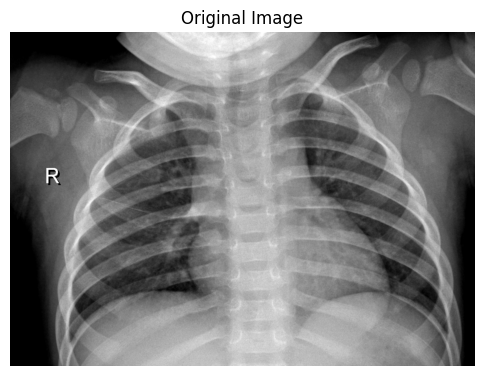

In [16]:
plt.figure(figsize=(6,6))

plt.imshow(
    original_image,
    cmap="gray"
)

plt.title("Original Image")

plt.axis("off")

plt.show()

In [17]:
transformed = train_transform(
    original_image
)

In [18]:
print(transformed.shape)

torch.Size([3, 224, 224])


In [19]:
image = transformed.permute(
    1,
    2,
    0
)

image = (
    image * 0.5
) + 0.5

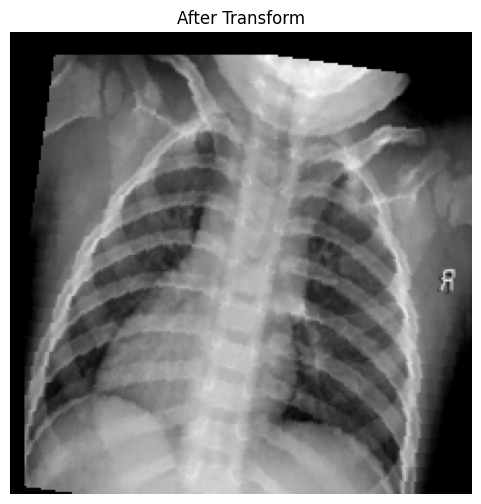

In [20]:
plt.figure(figsize=(6,6))

plt.imshow(
    image.numpy()
)

plt.title(
    "After Transform"
)

plt.axis("off")

plt.show()

In [21]:
import pickle

with open(
    "../results/metrics/train_val_split.pkl",
    "wb"
) as f:

    pickle.dump(
        {
            "X_train": X_train,
            "X_val": X_val,
            "y_train": y_train,
            "y_val": y_val
        },
        f
    )

In [22]:
import pickle

with open(
    "../results/metrics/train_val_split.pkl",
    "rb"
) as f:

    split_data = pickle.load(f)

X_train = split_data["X_train"]
X_val = split_data["X_val"]

y_train = split_data["y_train"]
y_val = split_data["y_val"]